In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/googleplaystore.csv')
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [18]:
data.describe(include="all")

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
data.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [20]:
data["Rating"] = data["Rating"].fillna(data["Rating"].mean())

In [21]:
data["Type"] = data["Type"].fillna(data["Type"].mode()[0])
data["Content Rating"] = data["Content Rating"].fillna(data["Content Rating"].mode()[0])

data = data.dropna(subset=["Current Ver", "Android Ver"])


In [22]:
data["Reviews"] = pd.to_numeric(data["Reviews"], errors='coerce')

In [23]:
data["Installs"] = data["Installs"].str.replace("+", "", regex=False)
data["Installs"] = data["Installs"].str.replace(",", "", regex=False)
data["Installs"] = pd.to_numeric(data["Installs"], errors="coerce")

In [24]:
data["Price"] = data["Price"].str.replace("$", "", regex=False)
data["Price"] = pd.to_numeric(data["Price"], errors="coerce")

In [25]:
def convert_size(x):
    if "M" in x:
        return float(x.replace("M", ""))
    elif "k" in x:
        return float(x.replace("k", "")) / 1024
    else:
        return np.nan

data["Size"] = data["Size"].apply(convert_size)

In [26]:
data["Size"] = data["Size"].fillna(data["Size"].mean())

In [27]:
data["Last Updated"] = pd.to_datetime(data["Last Updated"])

In [28]:
cat_cols = ["Category", "Genres", "Type", "Content Rating"]

for col in cat_cols:
    data[col] = data[col].astype("category")

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10830 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10830 non-null  object        
 1   Category        10830 non-null  category      
 2   Rating          10830 non-null  float64       
 3   Reviews         10830 non-null  int64         
 4   Size            10830 non-null  float64       
 5   Installs        10830 non-null  int64         
 6   Type            10830 non-null  category      
 7   Price           10830 non-null  float64       
 8   Content Rating  10830 non-null  category      
 9   Genres          10830 non-null  category      
 10  Last Updated    10830 non-null  datetime64[ns]
 11  Current Ver     10830 non-null  object        
 12  Android Ver     10830 non-null  object        
dtypes: category(4), datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 895.0+ KB


In [31]:
data.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [32]:
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


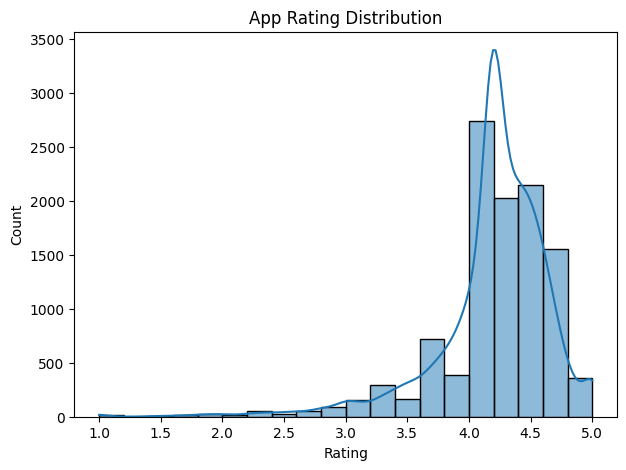

In [33]:
plt.figure(figsize=(7,5))
sns.histplot(data["Rating"], bins=20, kde=True)
plt.title("App Rating Distribution")
plt.show()

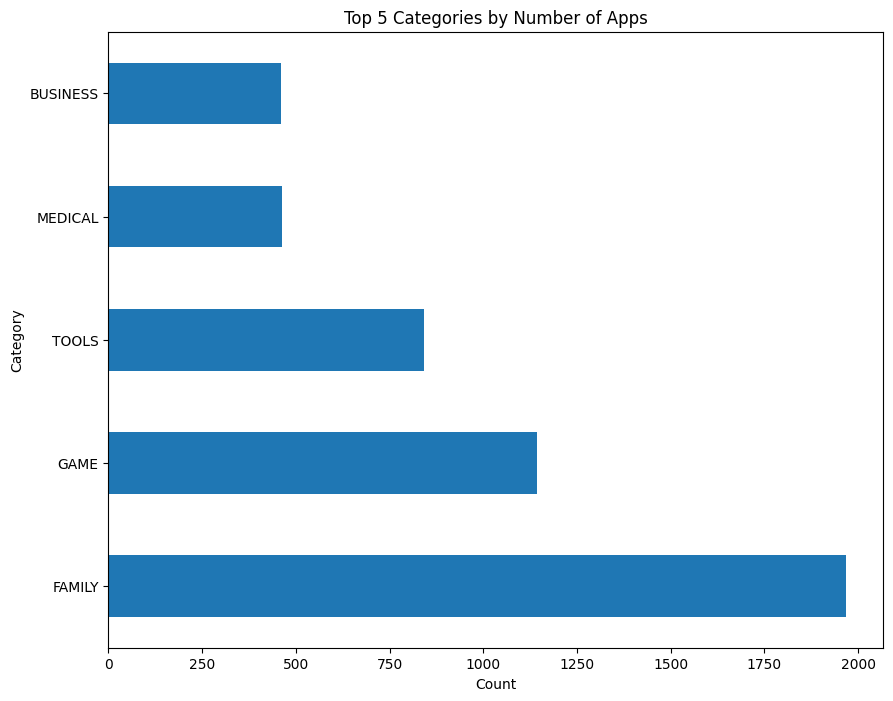

In [46]:
plt.figure(figsize=(10,8))
data["Category"].value_counts().head(5).plot(kind='barh')
plt.title("Top 5 Categories by Number of Apps")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

/tmp/ipython-input-1950942573.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_stats = data.groupby("Category")["Installs"].agg(["mean", "std"])


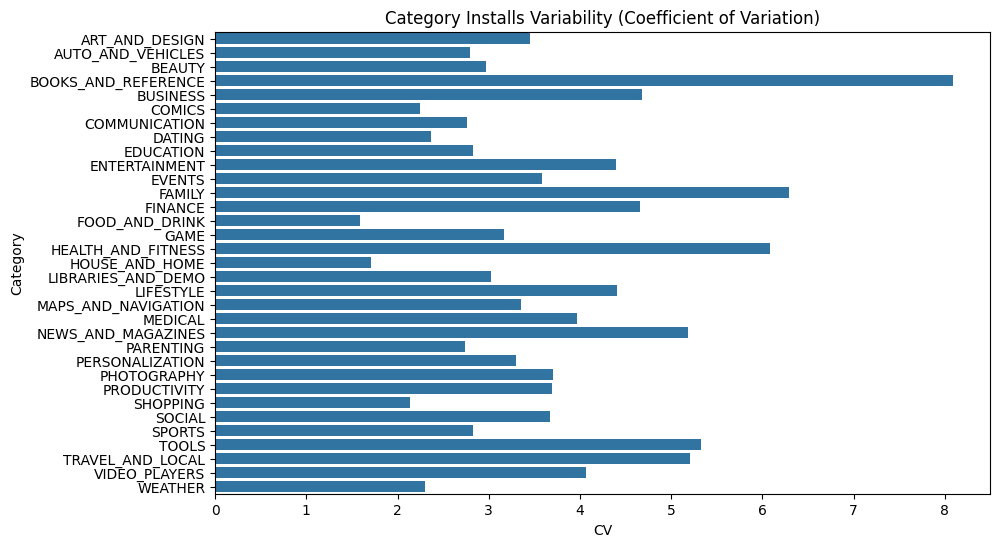

In [48]:
cat_stats = data.groupby("Category")["Installs"].agg(["mean", "std"])
cat_stats["CV"] = cat_stats["std"] / cat_stats["mean"]
cat_stats = cat_stats.sort_values("CV", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(y=cat_stats.index, x=cat_stats["CV"])
plt.title("Category Installs Variability (Coefficient of Variation)")
plt.show()

/tmp/ipython-input-669248762.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_group = data.groupby("Genres")[["Rating", "Installs", "Reviews"]].mean()


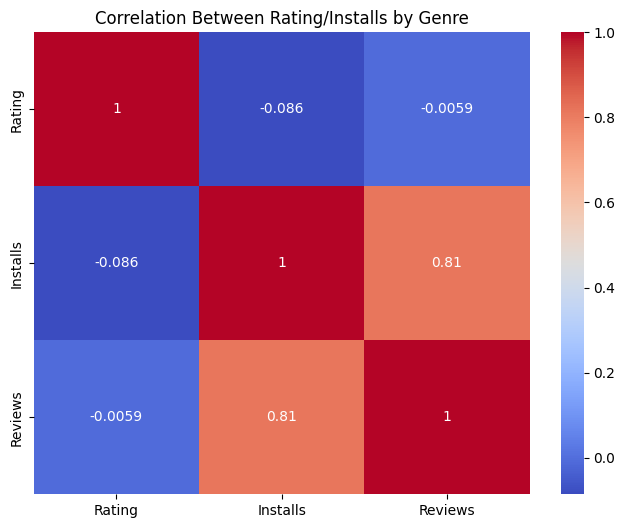

In [40]:
genre_group = data.groupby("Genres")[["Rating", "Installs", "Reviews"]].mean()
plt.figure(figsize=(8,6))
sns.heatmap(genre_group.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Rating/Installs by Genre")
plt.show()